# Background estimation

## 🔍 1. Query Data with DataBrowser

The `DataBrowser` class allows us to query and filter our synced data. Here we'll explore the available keys and their values to understand what data we have access to.


Let's filter our data to find specific images. We'll search for:
- **Target**: T00528
- **Telescope**: 7DT16  
- **Filter**: r-band
- **Pattern**: Files ending with `*100.fits`


In [1]:
from ezphot.utils import DataBrowser
dbrowser = DataBrowser('scidata')
dbrowser.objname = 'T00528'
dbrowser.telname = '7DT16'
dbrowser.filter = 'r'
target_imgset = dbrowser.search('*100.fits', return_type = 'science')
target_imglist = target_imgset.target_images

[INFO] Found 90 files matching '/home/hhchoi1022/ezphot/data/scidata/*/*/T00528/7DT16/r/*100.fits'


Loading Science Images: 100%|██████████| 90/90 [00:01<00:00, 78.30it/s]


## 2. Background Estimation

Background estimation is crucial for accurate photometry and image analysis.

- **Estimate background** using the SEP (Source Extractor Python) algorithm
- **Apply source masking** to improve background estimation

> **Science Note**: Background estimation removes sky brightness and instrumental effects, revealing the true astronomical sources in your images.

### 2.1. Basic Background Estimation

In [2]:
target_img = target_imglist[0]

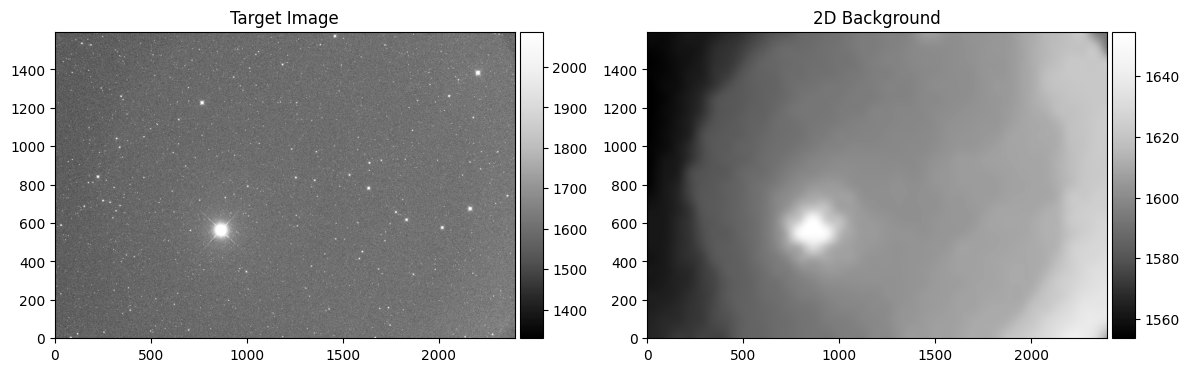

Cleared data and header from memory.


In [3]:
# Calculate the background map
target_bkg = target_img.calculate_bkg(
    target_srcmask = None,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 256,
    filter_size = 3,
    save = False,
    verbose = True,
    visualize = True
)
# Clear the memory
target_bkg.clear(verbose = True)

### 2.2. Advanced Background Estimation

Sometimes the background model may include real sources like saturated stars or extended objects. In such cases, you can apply source masks to improve the background estimation.

> **💡 Pro Tip**: Source masking helps create cleaner background models by excluding bright objects that could bias the background calculation.


#### 2.2.1. Automatic Source Mask Generation 

Masking source... [sigma = 5.0, mask_radius_factor = 2]
5675 non-saturated, 105 saturated sources
5780 sources masked.


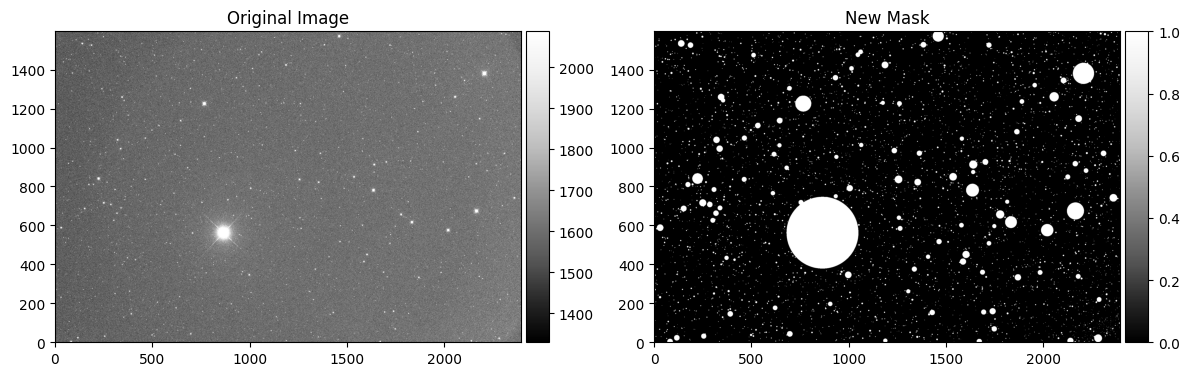

Iteration 1
External mask is loaded.
Masking source... [sigma = 5.0, mask_radius_factor = 2]
389 non-saturated, 0 saturated sources
389 sources masked.


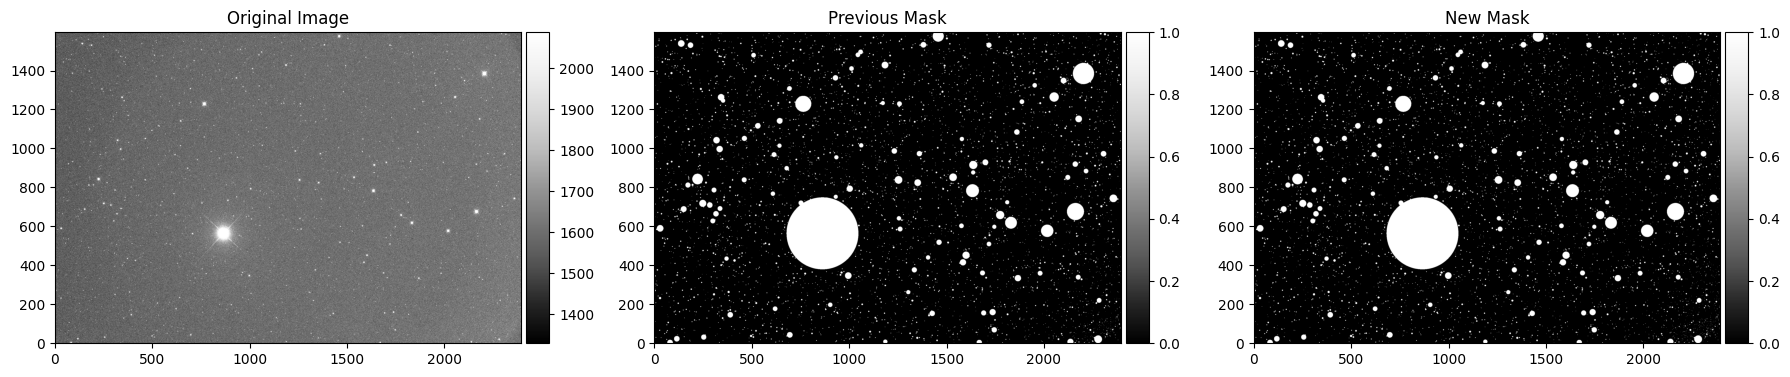

Iteration 2
External mask is loaded.
Masking source... [sigma = 5.0, mask_radius_factor = 2]
4 non-saturated, 0 saturated sources
4 sources masked.


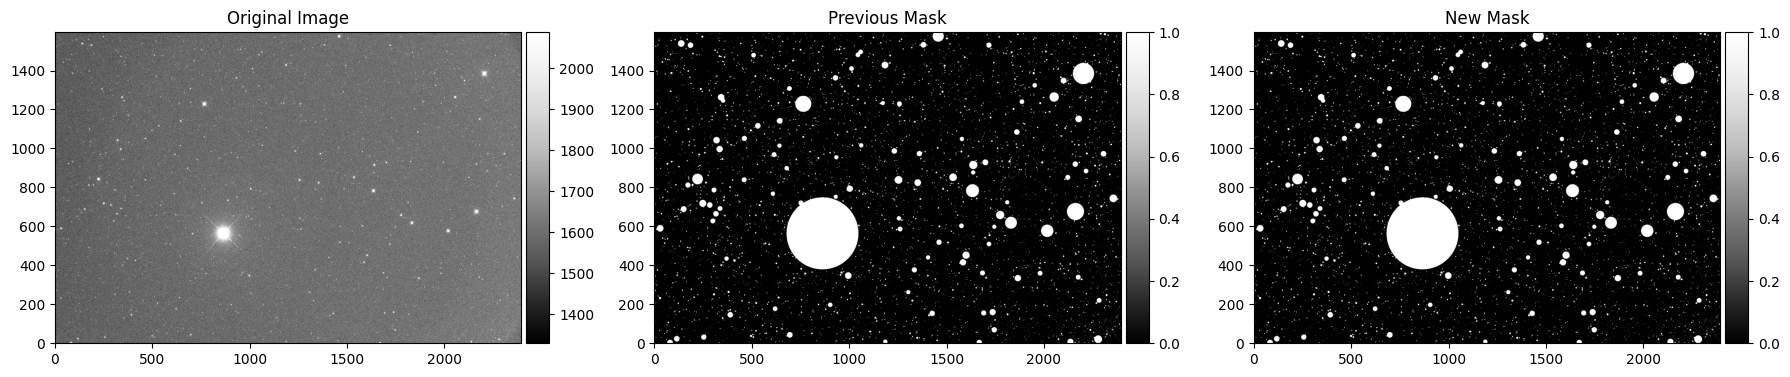

In [14]:
target_srcmask = target_img.calculate_sourcemask(
    target_srcmask = None,
    sigma = 5.0,
    mask_radius_factor = 2,
    saturation_level = 50000,
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False
)
# You can also iteratively apply source masking to the existing source mask,
for i in range(2):
    print('Iteration', i+1)
    target_srcmask = target_img.calculate_sourcemask(
        target_srcmask = target_srcmask,
        sigma = 5.0,
        mask_radius_factor = 2,
        saturation_level = 50000,
    )


#### 2.2.2. Manual Mask Generation

Added circular mask at (325.37, -77.39) with radius 300arcsec


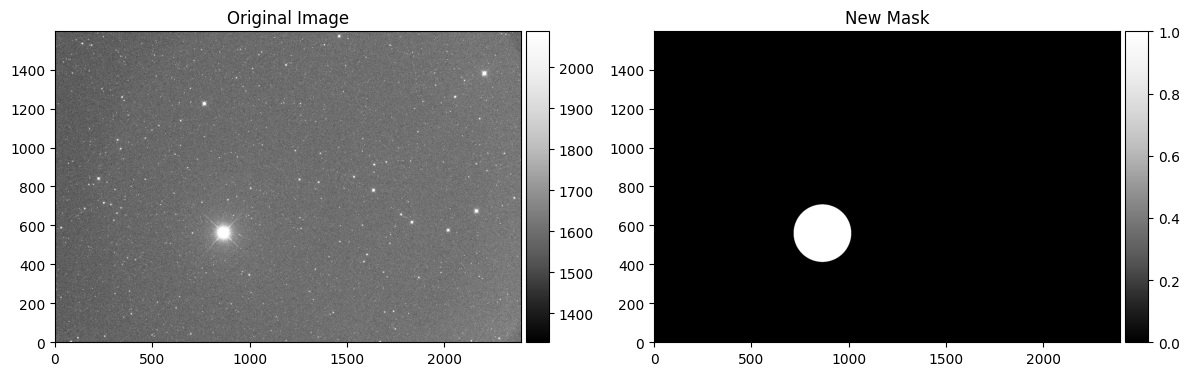

In [15]:
# If you wish to add manual source mask to reject the extended sources when background modeling,
from ezphot.methods import MaskGenerator
maskgen = MaskGenerator()
target_srcmask = maskgen.mask_circle(
    target_img = target_img,
    target_mask = None,
    mask_type = 'source',
    x_position = 325.37,
    y_position = -77.393,
    radius_arcsec = 300,
    unit = 'coord',
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False)

External mask is loaded.


Added circular mask at (325.07, -77.09) with radius 100arcsec


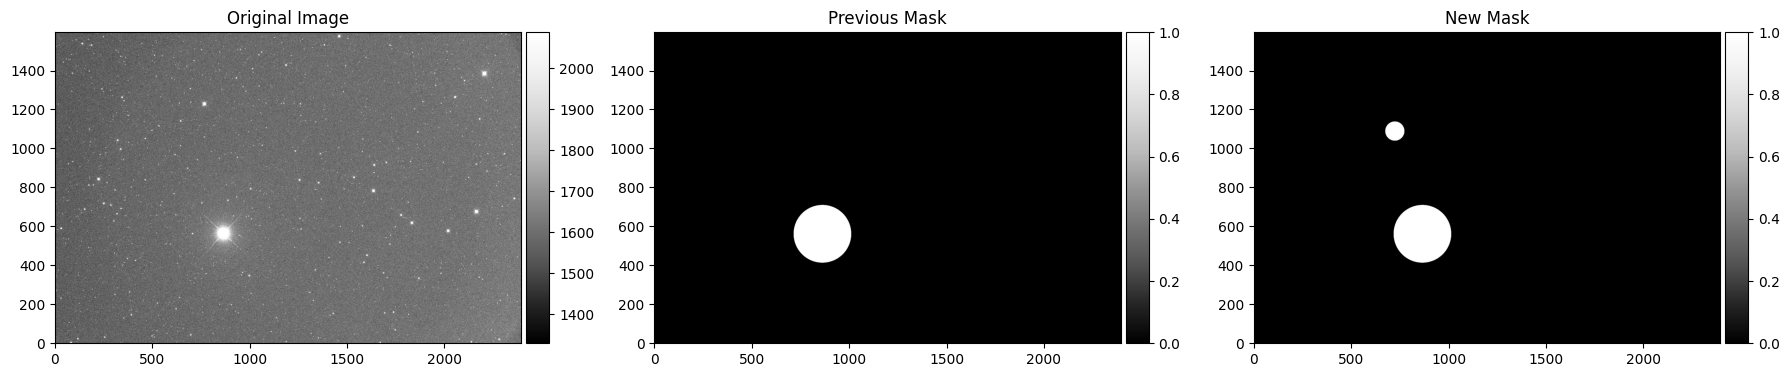

In [16]:
# Or If you wish to add manual source mask to the existing source mask,
target_srcmask = maskgen.mask_circle(
    target_img = target_img,
    target_mask = target_srcmask,
    mask_type = 'source',
    x_position = 325.07,
    y_position = -77.093,
    radius_arcsec = 100,
    unit = 'coord',
    save = False,
    verbose = True,
    visualize = True,
    save_fig = False)

#### 2.2.3. Re-generation of Background Map with Source Mask


External mask is loaded.


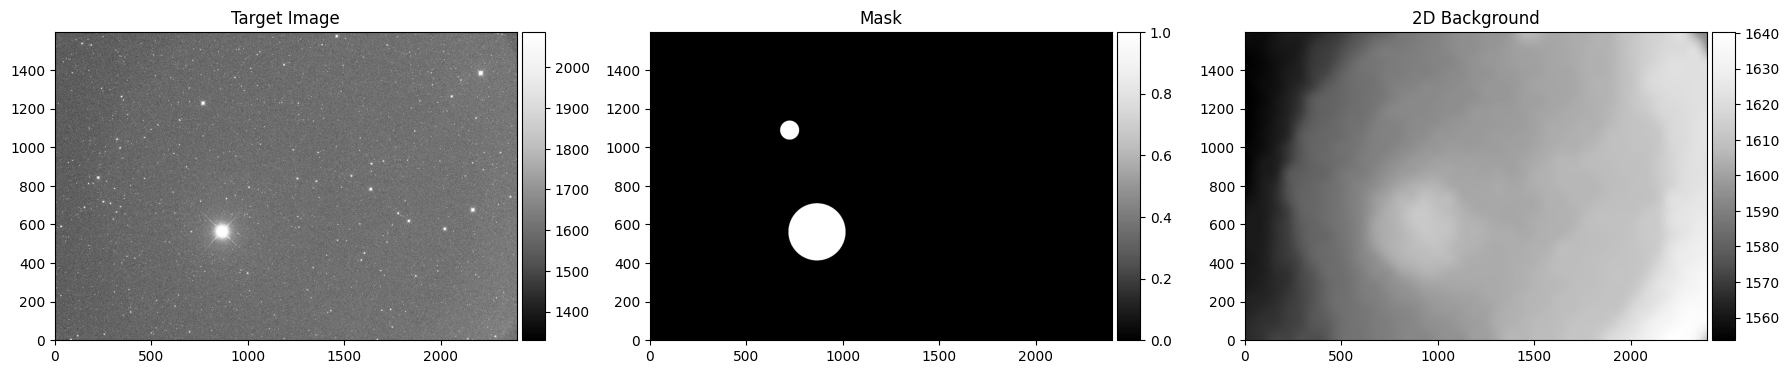

In [17]:
target_bkg_with_srcmask = target_img.calculate_bkg(
    target_srcmask = target_srcmask,
    target_ivpmask = None,
    is_2D_bkg = True,
    box_size = 256,
    filter_size = 3,
)

In [18]:
# Run for all target_imglist with multiprocessing
from multiprocessing import Pool
from tqdm import tqdm

def calculate_bkg(target_img):    
    target_srcmask = target_img.calculate_sourcemask(   
        sigma = 5.0,
        mask_radius_factor = 2,
        saturation_level = 50000,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )
    target_img.calculate_bkg(
        target_srcmask = target_srcmask,
        target_ivpmask = None,
        is_2D_bkg = True,
        box_size = 128,
        filter_size = 3,
        save = True,
        verbose = False,
        visualize = False,
        save_fig = False
    )    
                
    target_srcmask.clear(verbose = False)
    target_bkg.clear(verbose = False)
    
with Pool(processes = 16) as pool:
    # Use tqdm with imap to show progress
    list(tqdm(pool.imap(calculate_bkg, target_imglist), 
              total=len(target_imglist), 
              desc="Calculating backgrounds"))


Calculating backgrounds: 100%|██████████| 90/90 [04:22<00:00,  2.91s/it]
